# Import libraries

In [1]:
import pandas as pd
!pip install pandas pyarrow

# Import data

In [2]:
taxi_data = pd.read_parquet(r"C:\Users\HP\Desktop\new-york-taxi-analysis\data\yellow_tripdata_2019-01.parquet")
taxi_data.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,1,2019-01-01 00:46:40,2019-01-01 00:53:20,1.0,1.5,1.0,N,151,239,1,7.0,0.5,0.5,1.65,0.0,0.3,9.95,NaN,None
1,1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,N,239,246,1,14.0,0.5,0.5,1.00,0.0,0.3,16.30,NaN,None
2,2,2018-12-21 13:48:30,2018-12-21 13:52:40,3.0,0.0,1.0,N,236,236,1,4.5,0.5,0.5,0.00,0.0,0.3,5.80,NaN,None
3,2,2018-11-28 15:52:25,2018-11-28 15:55:45,5.0,0.0,1.0,N,193,193,2,3.5,0.5,0.5,0.00,0.0,0.3,7.55,NaN,None
4,2,2018-11-28 15:56:57,2018-11-28 15:58:33,5.0,0.0,2.0,N,193,193,2,52.0,0.0,0.5,0.00,0.0,0.3,55.55,NaN,None


In [3]:
taxi_data.shape

(7696617, 19)

# Data exploration

In [4]:
taxi_data.columns

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee'],
      dtype='object')

In [5]:
taxi_data = taxi_data[['tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID','PULocationID',
       'DOLocationID', 'payment_type',  'total_amount', 'fare_amount']]

array([[<Axes: title={'center': 'tpep_pickup_datetime'}>,
        <Axes: title={'center': 'tpep_dropoff_datetime'}>,
        <Axes: title={'center': 'passenger_count'}>],
       [<Axes: title={'center': 'trip_distance'}>,
        <Axes: title={'center': 'RatecodeID'}>,
        <Axes: title={'center': 'PULocationID'}>],
       [<Axes: title={'center': 'DOLocationID'}>,
        <Axes: title={'center': 'payment_type'}>,
        <Axes: title={'center': 'total_amount'}>],
       [<Axes: title={'center': 'fare_amount'}>, <Axes: >, <Axes: >]],
      dtype=object)

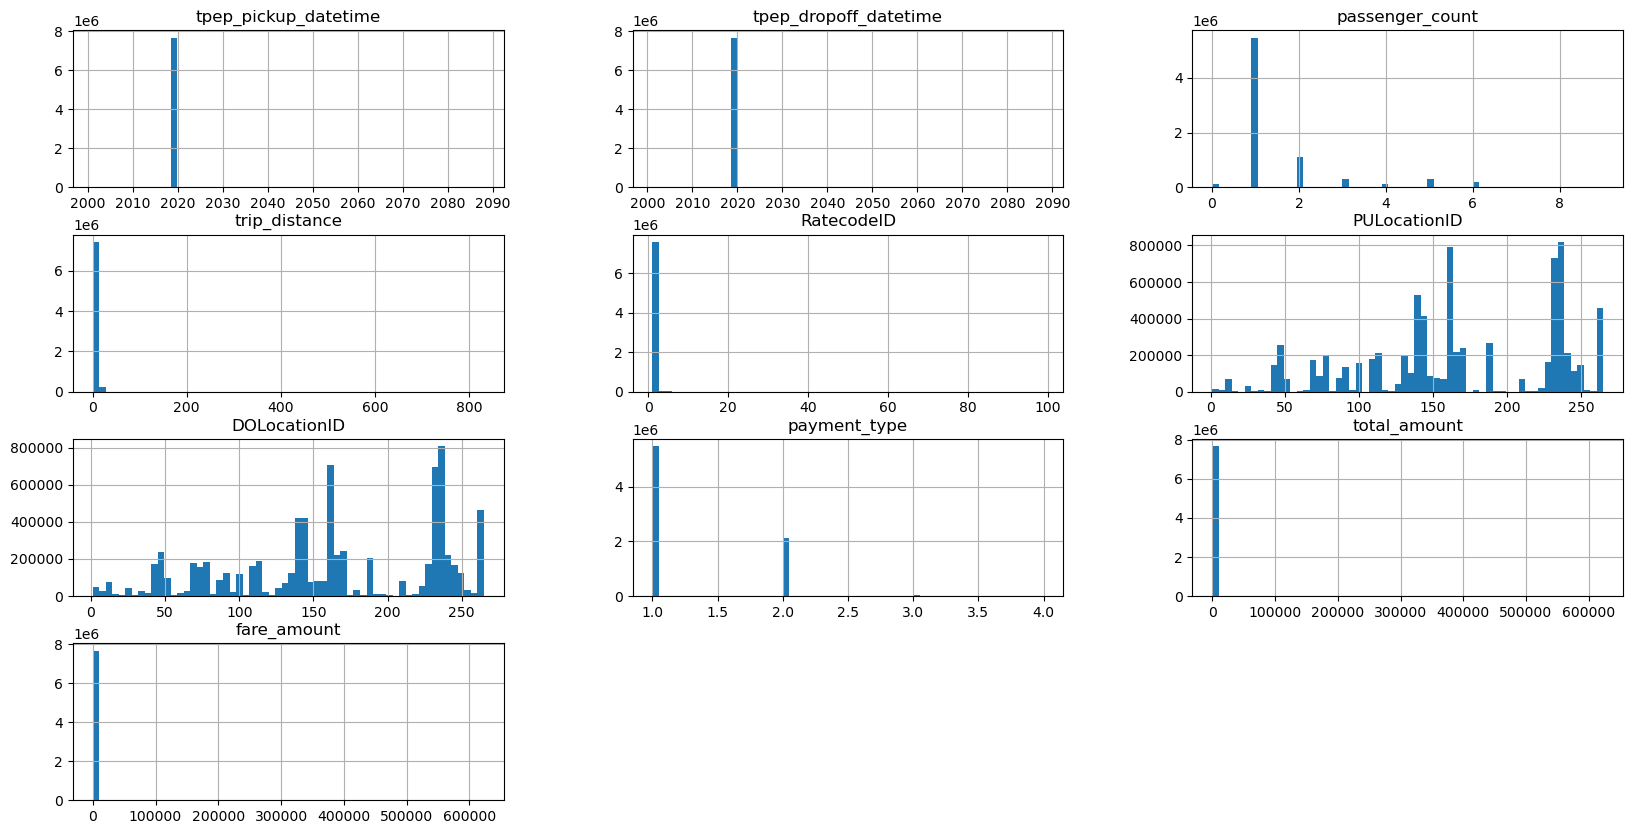

In [6]:

import numpy as np
taxi_data_clean = taxi_data.replace([np.inf, -np.inf], np.nan).dropna()
taxi_data_clean.hist(figsize=(20,10), bins=60)

In [7]:
taxi_data['RatecodeID'].value_counts()

RatecodeID
1.0     7430288
2.0      166093
5.0       54570
3.0       11801
4.0        4895
99.0        252
6.0          46
Name: count, dtype: int64

<Axes: xlabel='index', ylabel='fare_amount'>

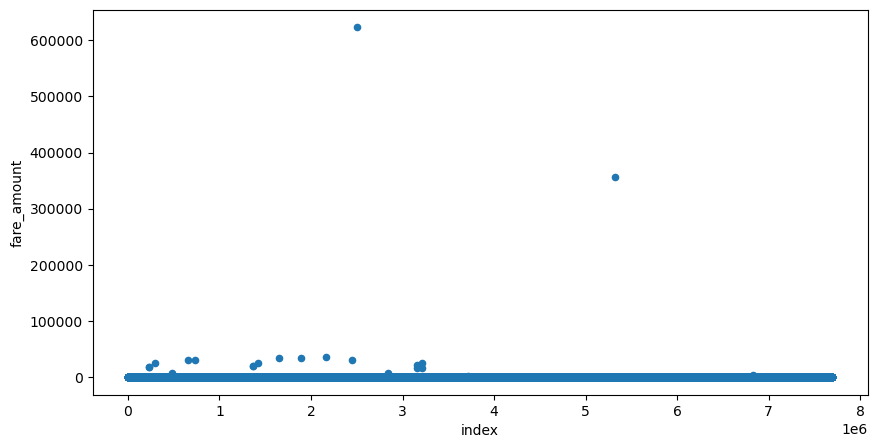

In [8]:
taxi_data.reset_index().plot(kind='scatter', y='fare_amount', x='index', figsize=(10,5))

<Axes: xlabel='index', ylabel='fare_amount'>

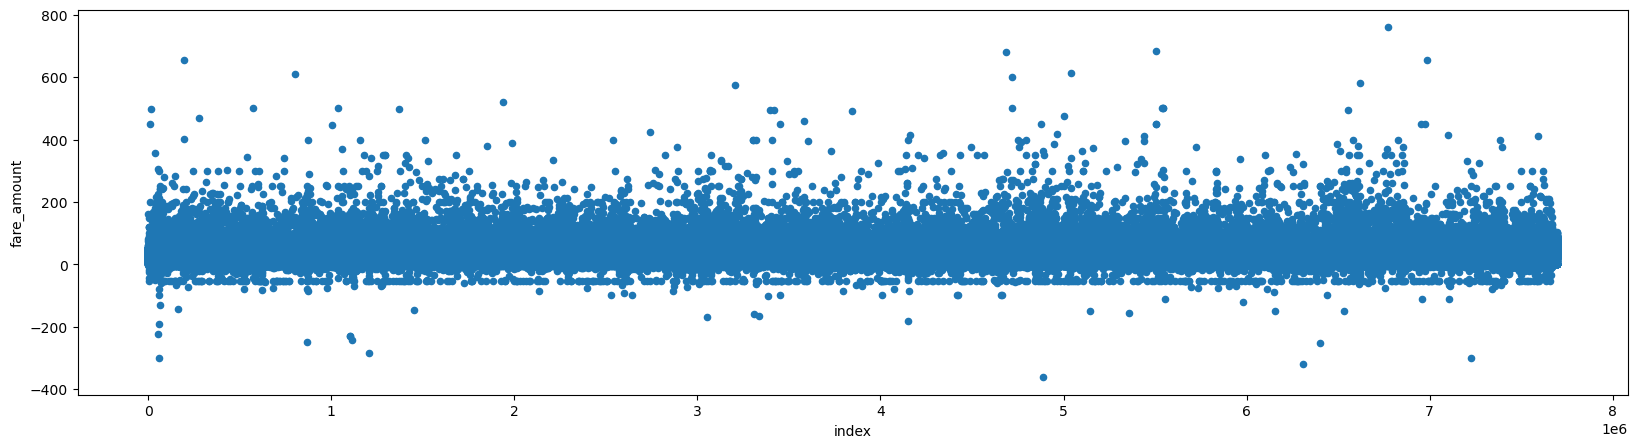

In [9]:
taxi_data[taxi_data['fare_amount']<1000].reset_index().plot(kind='scatter', y='fare_amount', x='index', figsize=(20,5))

### Two things to deal with: negative values and very high values. Let's first look at negative values.

(7129, 10)


<Axes: xlabel='index', ylabel='fare_amount'>

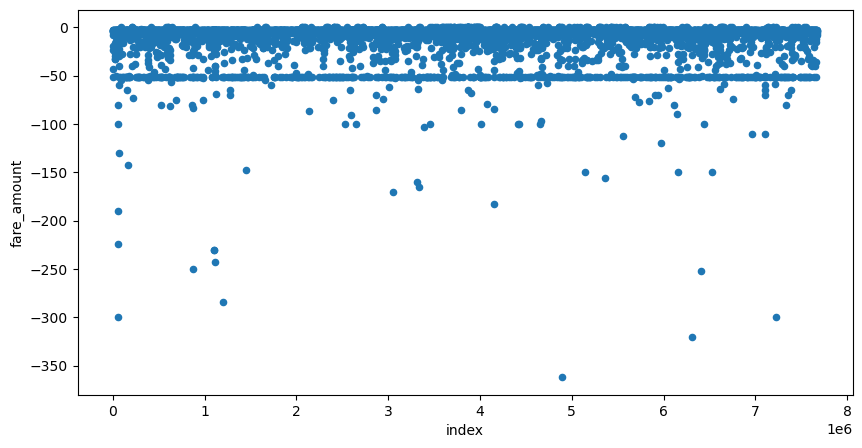

In [10]:
print(taxi_data[taxi_data['fare_amount']<0].shape)
taxi_data[taxi_data['fare_amount']<0].reset_index().plot(kind='scatter', y='fare_amount', x='index', figsize=(10,5))

In [11]:
taxi_data[taxi_data['fare_amount']<0].head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,fare_amount
663,2019-01-01 00:32:56,2019-01-01 00:33:35,2.0,0.10,1.0,148,148,3,-3.8,-2.5
2402,2019-01-01 00:14:18,2019-01-01 00:40:55,1.0,4.13,1.0,170,238,4,-20.3,-19.0
2541,2019-01-01 00:31:27,2019-01-01 00:42:39,1.0,1.35,1.0,162,234,4,-9.8,-8.5
2544,2019-01-01 00:45:57,2019-01-01 00:46:07,1.0,0.00,1.0,234,234,4,-3.8,-2.5
2547,2019-01-01 00:48:35,2019-01-01 00:49:59,1.0,0.16,1.0,234,234,4,-4.3,-3.0


<Axes: >

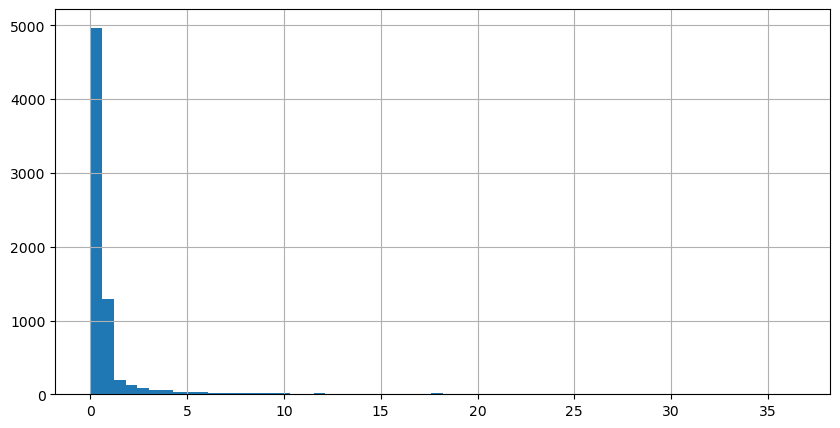

In [12]:
taxi_data[taxi_data['fare_amount']<0]['trip_distance'].hist(bins=60, figsize=(10,5))

In [13]:
print(taxi_data[taxi_data['fare_amount']==0].shape)
taxi_data[taxi_data['fare_amount']==0].head()

(2641, 10)


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,fare_amount
3552,2019-01-01 00:18:46,2019-01-01 00:18:46,1.0,0.0,5.0,186,264,2,0.0,0.0
9138,2019-01-01 00:41:47,2019-01-01 00:41:47,1.0,0.0,5.0,246,264,2,0.0,0.0
9556,2019-01-01 00:26:35,2019-01-01 00:26:35,1.0,0.0,5.0,68,264,2,10.5,0.0
12508,2019-01-01 00:11:16,2019-01-01 00:12:31,1.0,0.2,5.0,265,265,2,0.3,0.0
13256,2019-01-01 00:19:38,2019-01-01 00:20:35,1.0,0.0,1.0,193,193,1,0.0,0.0


<Axes: >

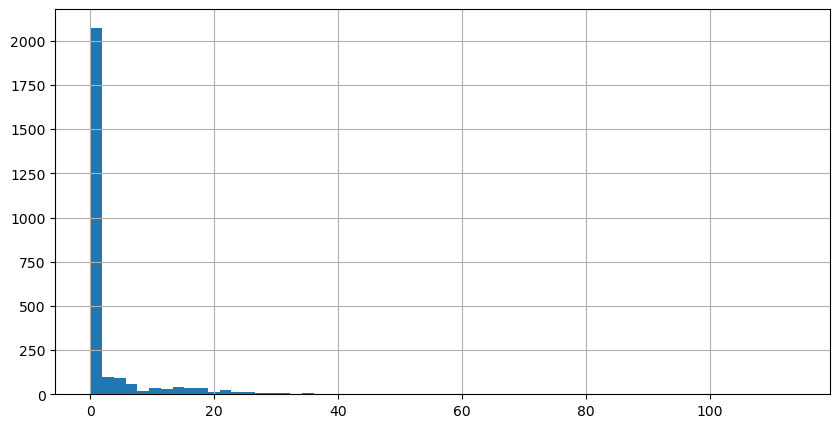

In [14]:
taxi_data[taxi_data['fare_amount']==0]['trip_distance'].hist(bins=60, figsize=(10,5))

In [15]:
taxi_data[taxi_data['fare_amount']==0]['trip_distance'].value_counts()

trip_distance
0.00     1590
0.10       92
0.20       52
0.30       37
0.40       23
         ... 
11.90       1
26.50       1
1.56        1
1.21        1
12.30       1
Name: count, Length: 423, dtype: int64

In [16]:

taxi_data['trip_distance'].value_counts()

trip_distance
0.80     169440
0.90     166745
0.70     163490
1.00     162426
1.10     151866
          ...  
38.68         1
47.66         1
56.53         1
82.49         1
44.81         1
Name: count, Length: 4390, dtype: int64

### We can safely get rid of the negative values. What about the very high values?

In [17]:
taxi_data[taxi_data['fare_amount']>100].shape


(4807, 10)

### We can agree to cut from $100 level.

In [18]:
taxi_data_filtered = taxi_data[(taxi_data['fare_amount'] >= 0) & (taxi_data['fare_amount'] <= 100)]

In [19]:
print(taxi_data.shape)
taxi_data_filtered.shape

(7696617, 10)


(7684681, 10)

In [20]:
print(taxi_data_filtered['total_amount'].min())
print(taxi_data_filtered['total_amount'].max())

0.0
3345.3


In [21]:
taxi_data_filtered[(taxi_data_filtered['total_amount'] > 180)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,fare_amount
116377,2019-01-01 15:09:26,2019-01-01 15:47:13,5.0,13.36,5.0,88,265,1,181.60,80.0
149361,2019-01-01 18:47:16,2019-01-01 19:16:25,2.0,17.20,3.0,186,1,2,426.80,64.0
156003,2019-01-01 19:45:26,2019-01-01 19:45:28,1.0,0.00,1.0,264,235,1,203.30,2.5
380604,2019-01-02 22:24:41,2019-01-02 23:05:46,1.0,19.90,2.0,132,143,3,628.80,52.0
393051,2019-01-03 01:42:09,2019-01-03 01:44:02,1.0,0.00,2.0,133,133,1,452.80,52.0
626077,2019-01-04 06:23:15,2019-01-04 06:26:02,1.0,0.10,2.0,243,243,3,629.27,52.0
844569,2019-01-04 23:10:40,2019-01-04 23:11:05,1.0,0.00,1.0,265,265,1,203.80,2.5
1072494,2019-01-05 23:19:48,2019-01-05 23:25:06,1.0,1.11,1.0,239,24,1,795.05,6.5
1083745,2019-01-06 00:43:54,2019-01-06 02:30:40,6.0,10.15,1.0,226,28,1,490.80,68.5
1199876,2019-01-06 15:26:16,2019-01-06 16:16:59,1.0,18.32,4.0,255,1,1,225.30,89.0


In [22]:
taxi_data_filtered = taxi_data[(taxi_data['total_amount'] >= 0) & (taxi_data['total_amount'] <= 180)]

<Axes: xlabel='index', ylabel='fare_amount'>

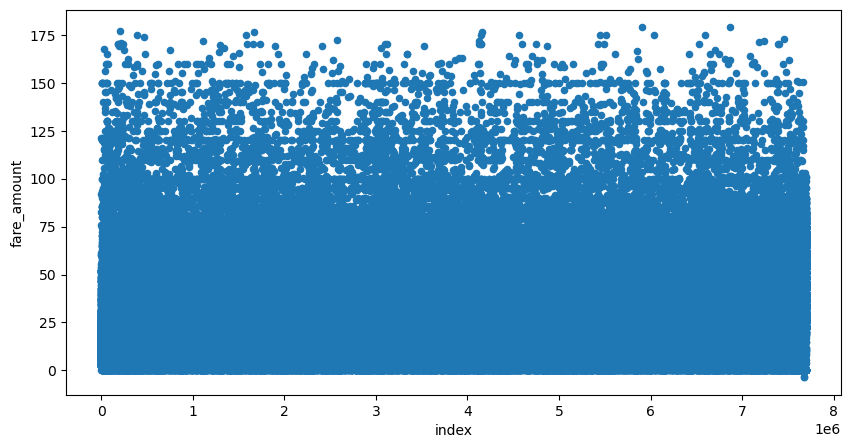

In [23]:
taxi_data_filtered.reset_index().plot(
    kind='scatter',
    x='index',
    y='fare_amount',
    figsize=(10,5)
)

In [24]:
taxi_data_filtered = taxi_data_filtered[
    (taxi_data_filtered['trip_distance'] > 0) &
    (taxi_data_filtered['trip_distance'] < 40)
]

<Axes: xlabel='index', ylabel='trip_distance'>

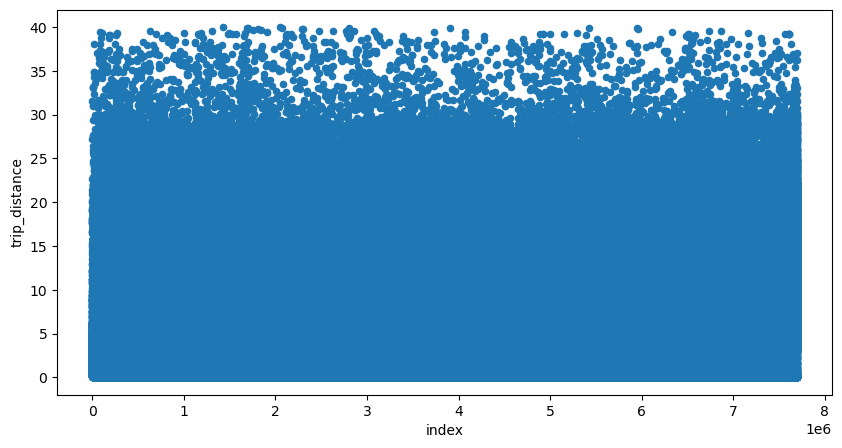

In [25]:
taxi_data_filtered.reset_index().plot(
    kind='scatter',
    x='index',
    y='trip_distance',
    figsize=(10,5)
)

Removing rows where trip distance and total amount is zero.

In [26]:
taxi_data[(taxi_data['trip_distance'] == 0) & (taxi_data['total_amount'] == 0)]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,fare_amount
3552,2019-01-01 00:18:46,2019-01-01 00:18:46,1.0,0.0,5.0,186,264,2,0.0,0.0
9138,2019-01-01 00:41:47,2019-01-01 00:41:47,1.0,0.0,5.0,246,264,2,0.0,0.0
13256,2019-01-01 00:19:38,2019-01-01 00:20:35,1.0,0.0,1.0,193,193,1,0.0,0.0
13257,2019-01-01 00:43:34,2019-01-01 00:43:34,1.0,0.0,1.0,7,7,2,0.0,0.0
13258,2019-01-01 00:02:52,2019-01-01 00:02:52,1.0,0.0,1.0,264,7,2,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
7695990,2019-01-31 08:40:00,2019-01-31 08:40:00,NaN,0.0,NaN,264,14,0,0.0,0.0
7696038,2019-01-31 09:27:00,2019-01-31 09:27:00,NaN,0.0,NaN,264,256,0,0.0,0.0
7696097,2019-01-31 11:54:00,2019-01-31 11:54:00,NaN,0.0,NaN,161,161,0,0.0,0.0
7696367,2019-01-31 16:17:00,2019-01-31 16:18:00,NaN,0.0,NaN,100,100,0,0.0,0.0


In [27]:
taxi_data = taxi_data[
    (taxi_data['trip_distance'] > 2) &
    (taxi_data['trip_distance'] < 30)
]

taxi_data = taxi_data[
    (taxi_data['fare_amount'] > 2) &
    (taxi_data['fare_amount'] < 95)
]


In [28]:
print(taxi_data.shape)

(2865995, 10)


In [29]:
taxi_data['fare_per_mile'] = taxi_data['fare_amount'] / taxi_data['trip_distance']

In [30]:
taxi_data[taxi_data['fare_per_mile']>4].shape


(1436905, 11)

In [31]:

taxi_data = taxi_data[
    (taxi_data['fare_per_mile'] > 1.5) &
    (taxi_data['fare_per_mile'] < 7)]

taxi_data = taxi_data[
    (taxi_data['fare_amount'] != 52)]

Text(0, 0.5, 'Fare Amount')

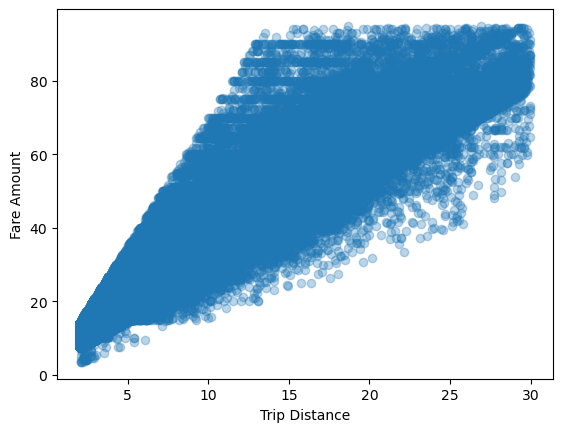

In [32]:
import matplotlib.pyplot as plt
plt.scatter(taxi_data['trip_distance'], taxi_data['fare_amount'], alpha=0.3)
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")

In [33]:
taxi_data[taxi_data['passenger_count']<=0]['RatecodeID'].value_counts()
taxi_data_filtered[
    (taxi_data_filtered['passenger_count'] == 0)
]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,fare_amount
156,2019-01-01 00:32:24,2019-01-01 00:33:21,0.0,5.3,1.0,50,50,1,4.55,2.5
228,2019-01-01 00:00:50,2019-01-01 00:31:48,0.0,18.0,2.0,132,140,1,59.80,52.0
229,2019-01-01 00:38:32,2019-01-01 01:09:51,0.0,8.9,1.0,229,37,1,38.50,29.5
298,2019-01-01 00:45:19,2019-01-01 00:55:53,0.0,1.0,1.0,107,170,2,9.30,8.0
905,2019-01-01 00:20:15,2019-01-01 00:26:42,0.0,0.7,1.0,90,249,1,8.30,6.0
...,...,...,...,...,...,...,...,...,...,...
7667705,2019-01-31 23:56:07,2019-02-01 00:13:46,0.0,2.8,1.0,264,264,1,16.30,13.5
7667734,2019-01-31 23:36:42,2019-01-31 23:57:43,0.0,4.8,1.0,161,13,1,20.80,17.5
7667765,2019-01-31 23:06:23,2019-01-31 23:18:20,0.0,3.2,1.0,68,239,1,15.95,12.0
7667917,2019-01-31 23:06:51,2019-01-31 23:15:06,0.0,1.4,1.0,162,186,2,8.80,7.5


In [34]:
taxi_data_filtered['passenger_count'].value_counts()
taxi_data_filtered = taxi_data_filtered[
    ~taxi_data_filtered['passenger_count'].isin([6, 7, 8, 9])
]
taxi_data_filtered['passenger_count'].value_counts()

passenger_count
1.0    5409113
2.0    1106232
5.0     322339
3.0     312860
4.0     139870
0.0     115610
Name: count, dtype: int64

In [35]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          28350
trip_distance                0
RatecodeID               28350
PULocationID                 0
DOLocationID                 0
payment_type                 0
total_amount                 0
fare_amount                  0
dtype: int64

In [36]:
taxi_data_filtered[taxi_data_filtered['passenger_count'].isna()]

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,fare_amount
7667945,2019-01-01 00:38:45,2019-01-01 00:54:11,NaN,2.21,NaN,161,263,0,16.30,12.24
7667946,2019-01-01 01:56:58,2019-01-01 02:13:14,NaN,3.17,NaN,256,226,0,19.59,15.52
7667947,2019-01-01 01:59:06,2019-01-01 02:20:24,NaN,6.31,NaN,140,256,0,34.04,27.56
7667949,2019-01-01 02:44:00,2019-01-01 03:03:00,NaN,11.86,NaN,246,265,0,0.00,0.00
7667950,2019-01-01 02:47:00,2019-01-01 03:06:00,NaN,4.59,NaN,234,265,0,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...
7696611,2019-01-31 23:14:00,2019-01-31 23:29:00,NaN,5.45,NaN,41,136,0,32.50,28.95
7696612,2019-01-31 23:37:20,2019-02-01 00:10:43,NaN,10.24,NaN,142,95,0,0.00,0.00
7696613,2019-01-31 23:28:00,2019-01-31 23:50:50,NaN,12.43,NaN,48,213,0,54.60,48.80
7696614,2019-01-31 23:11:00,2019-01-31 23:46:00,NaN,9.14,NaN,159,246,0,54.60,51.05


In [37]:
taxi_data_filtered = taxi_data.copy()

In [38]:
total_rows = len(taxi_data_filtered)

invalid_rows = (
    taxi_data_filtered['passenger_count'].isna() &
    taxi_data_filtered['RatecodeID'].isna()
).sum()

print("Total rows:", total_rows)
print("Invalid rows:", invalid_rows)
print("Percentage:", invalid_rows / total_rows * 100)


Total rows: 2677809
Invalid rows: 26654
Percentage: 0.995365987641389


In [39]:
taxi_data_filtered = taxi_data_filtered.dropna(
    subset=['passenger_count', 'RatecodeID'],
    how='all'
)

In [40]:
taxi_data_filtered.isna().sum()

tpep_pickup_datetime     0
tpep_dropoff_datetime    0
passenger_count          0
trip_distance            0
RatecodeID               0
PULocationID             0
DOLocationID             0
payment_type             0
total_amount             0
fare_amount              0
fare_per_mile            0
dtype: int64

# Data Preparation

In [41]:
taxi_data_prepared = taxi_data_filtered.copy()

In [42]:
taxi_data_prepared.dtypes

tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
passenger_count                 float64
trip_distance                   float64
RatecodeID                      float64
PULocationID                      int64
DOLocationID                      int64
payment_type                      int64
total_amount                    float64
fare_amount                     float64
fare_per_mile                   float64
dtype: object

In [43]:
taxi_data['tpep_pickup_datetime'] = pd.to_datetime(taxi_data['tpep_pickup_datetime'])
taxi_data['tpep_dropoff_datetime'] = pd.to_datetime(taxi_data['tpep_dropoff_datetime'])
taxi_data['pickup_hour'] = taxi_data['tpep_pickup_datetime'].dt.hour
taxi_data['pickup_day'] = taxi_data['tpep_pickup_datetime'].dt.dayofweek

In [44]:
taxi_data_prepared['transaction_date'] = pd.to_datetime(taxi_data_prepared['tpep_pickup_datetime'].dt.date)
taxi_data_prepared['transaction_year'] = taxi_data_prepared['tpep_pickup_datetime'].dt.year
taxi_data_prepared['transaction_month'] = taxi_data_prepared['tpep_pickup_datetime'].dt.month
taxi_data_prepared['transaction_day'] =  taxi_data_prepared['tpep_pickup_datetime'].dt.day
taxi_data_prepared['transaction_hour'] = taxi_data_prepared['tpep_pickup_datetime'].dt.hour

In [45]:
taxi_data_prepared.head()

,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,PULocationID,DOLocationID,payment_type,total_amount,fare_amount,fare_per_mile,transaction_date,transaction_year,transaction_month,transaction_day,transaction_hour
1,2019-01-01 00:59:47,2019-01-01 01:18:59,1.0,2.6,1.0,239,246,1,16.30,14.0,5.384615,2019-01-01,2019,1,1,0
8,2019-01-01 00:32:01,2019-01-01 00:45:39,1.0,3.7,1.0,229,7,1,18.50,13.5,3.648649,2019-01-01,2019,1,1,0
9,2019-01-01 00:57:32,2019-01-01 01:09:32,2.0,2.1,1.0,141,234,1,13.00,10.0,4.761905,2019-01-01,2019,1,1,0
10,2019-01-01 00:24:04,2019-01-01 00:47:06,2.0,2.8,1.0,246,162,1,19.55,15.0,5.357143,2019-01-01,2019,1,1,0
12,2019-01-01 00:45:21,2019-01-01 01:31:05,1.0,8.7,1.0,163,25,1,42.95,34.5,3.965517,2019-01-01,2019,1,1,0


### We are working only on Jan 2019 data, we will be removing others.

In [46]:
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_year']==2019]
taxi_data_prepared = taxi_data_prepared[taxi_data_prepared['transaction_month']==1]
categorical_columns = ['transaction_date','transaction_day','transaction_hour']
numerical_columns = ['trip_distance','passenger_count','fare_amount','PULocationID']
all_needed_columns = categorical_columns + numerical_columns

In [47]:
main_taxi_df = taxi_data_prepared[all_needed_columns]
print(main_taxi_df.shape)
main_taxi_df.head()

(2650918, 7)


,transaction_date,transaction_day,transaction_hour,trip_distance,passenger_count,fare_amount,PULocationID
1,2019-01-01,1,0,2.6,1.0,14.0,239
8,2019-01-01,1,0,3.7,1.0,13.5,229
9,2019-01-01,1,0,2.1,2.0,10.0,141
10,2019-01-01,1,0,2.8,2.0,15.0,246
12,2019-01-01,1,0,8.7,1.0,34.5,163


<Axes: >

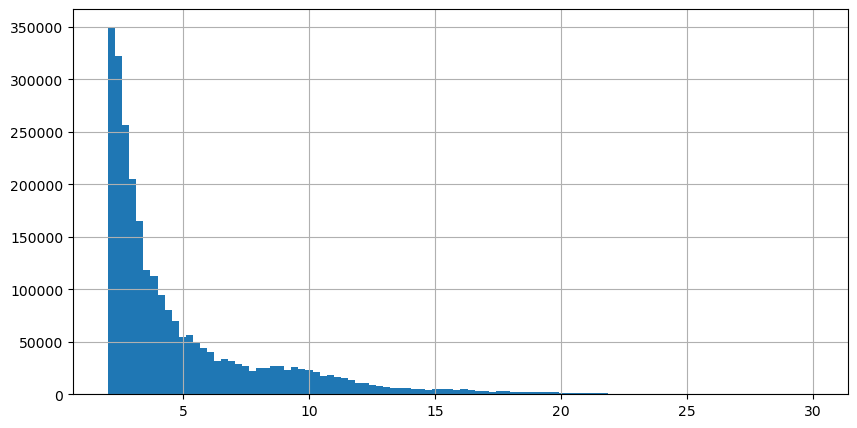

In [48]:
main_taxi_df['trip_distance'].hist(bins=100, figsize=(10,5))

<Axes: >

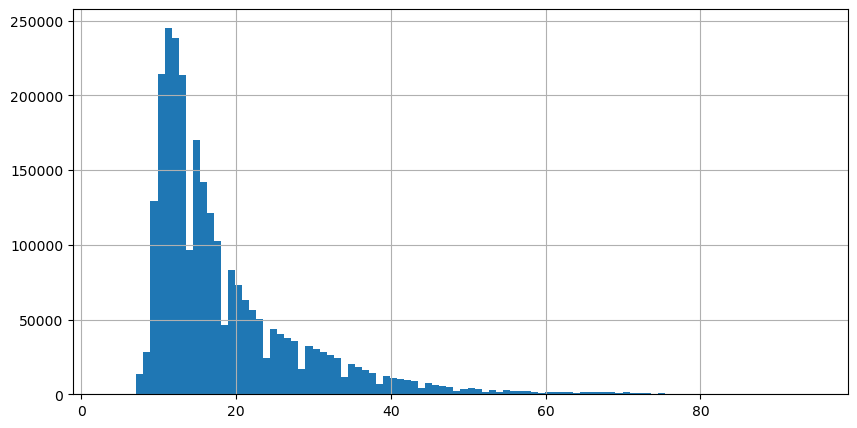

In [49]:
main_taxi_df['fare_amount'].hist(bins=100, figsize=(10,5))


# Benchmark Model

In [50]:
data_for_benchmark_model = main_taxi_df.copy()

In [51]:
categorical_features_benchmark = ['PULocationID','transaction_day','transaction_hour','passenger_count','trip_distance']
input_features_benchmark  = categorical_features_benchmark
target_feature_benchmark  = 'fare_amount'

In [52]:
data_for_benchmark_model
sample_df = data_for_benchmark_model.sample(100000, random_state=42)
sample_df.dropna(subset=[target_feature_benchmark], inplace=True)

In [53]:
X = sample_df[input_features_benchmark]
y = sample_df[target_feature_benchmark]
X = pd.get_dummies(X)
X = X.fillna(0)


### Train-test split

In [54]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42)

### Fit a model to the data

In [55]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    max_depth=20,
    random_state=42,
    n_jobs=-1)

model.fit(X_train, y_train)

,n_estimators,200
,criterion,'squared_error'
,max_depth,20
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [56]:

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from math import sqrt

rf = RandomForestRegressor(random_state=42) 
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print('Mean Absolute Error (MAE):', mae)
print('Mean Squared Error (MSE):', mse)
print('Root Mean Squared Error (RMSE):', rmse)
print('R² Score:', r2)

Mean Absolute Error (MAE): 1.6427832893650796
Mean Squared Error (MSE): 6.110317298951145
Root Mean Squared Error (RMSE): 2.4719056007362306
R² Score: 0.9418253468896343


Text(0, 0.5, 'Predicted Values')

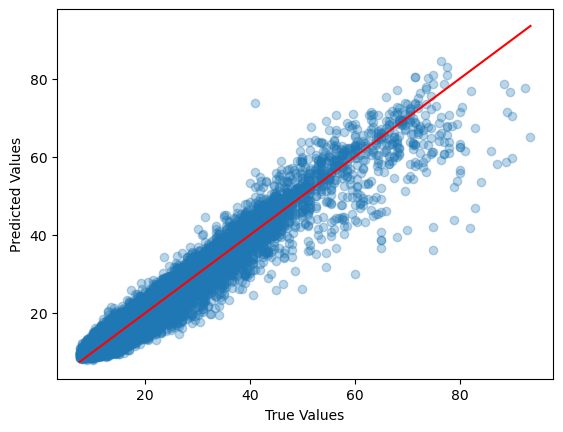

In [57]:
import matplotlib.pyplot as plt

data = {'True Values': y_test, 'Predicted Values': y_pred_rf}
results = pd.DataFrame(data)

plt.scatter(y_test, y_pred_rf, alpha=0.3)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color='red')
plt.xlabel("True Values")
plt.ylabel("Predicted Values")